In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datatattle/covid-19-nlp-text-classification")

print("Path to dataset files:", path)

100%|██████████| 4.38M/4.38M [00:01<00:00, 3.47MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/datatattle/covid-19-nlp-text-classification/versions/1


Part 1

   UserName  ScreenName   Location     TweetAt  \
0      3799       48751     London  16-03-2020   
1      3800       48752         UK  16-03-2020   
2      3801       48753  Vagabonds  16-03-2020   
3      3802       48754        NaN  16-03-2020   
4      3803       48755        NaN  16-03-2020   

                                       OriginalTweet           Sentiment  
0  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...             Neutral  
1  advice Talk to your neighbours family to excha...            Positive  
2  Coronavirus Australia: Woolworths to give elde...            Positive  
3  My food stock is not the only one which is emp...            Positive  
4  Me, ready to go at supermarket during the #COV...  Extremely Negative  

Dataset shape is (41157, 6)
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 column

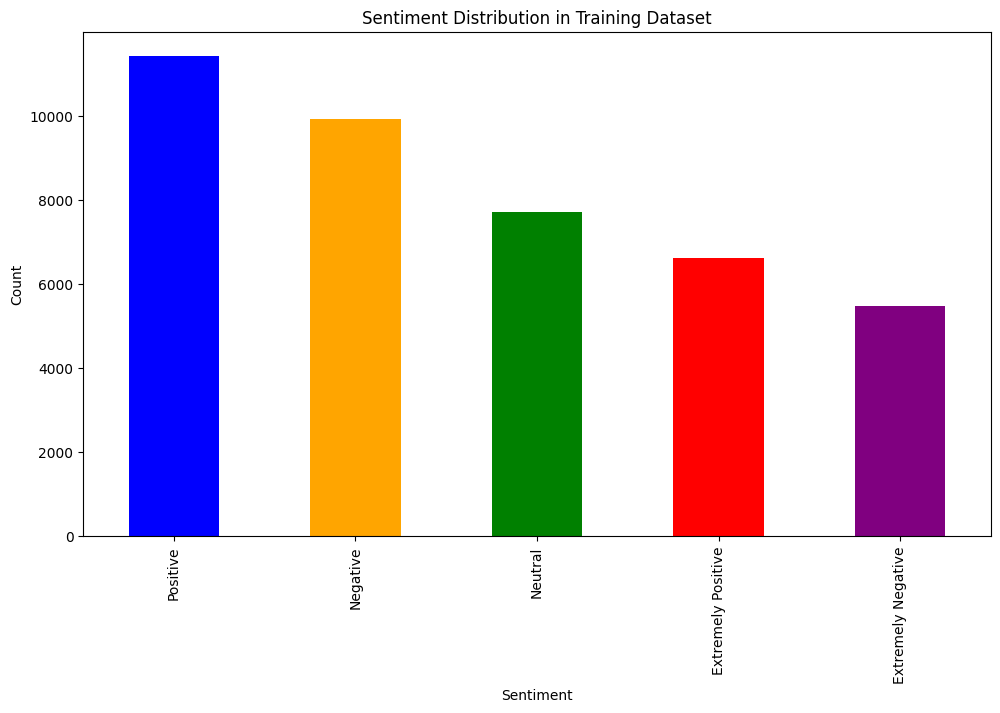

In [4]:
#step 1.1
!pip install pandas numpy matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

file_path = os.path.join(path, "Corona_NLP_train.csv")
file_path_test = os.path.join(path, "Corona_NLP_test.csv")

df_train = pd.read_csv(file_path, encoding="ISO-8859-1")
print(df_train.head())
print(f'\nDataset shape is {df_train.shape}')
print('$'*100)


print(f'\nDataset info:')
print(df_train.info())
print('$'*100)

sentiment_counts = df_train['Sentiment'].value_counts()

plt.figure(figsize=(10, 6))
plt.title('Sentiment Distribution in Training Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
sentiment_counts.plot(kind='bar', color=['blue', 'orange', 'green', 'red', 'purple'])
plt.show()

In [5]:
# step1.2

df_train['Text'] = df_train['OriginalTweet']
df_train['Label'] = df_train['Sentiment']
df_train = df_train.drop(columns=['OriginalTweet', 'Sentiment'])
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserName    41157 non-null  int64 
 1   ScreenName  41157 non-null  int64 
 2   Location    32567 non-null  object
 3   TweetAt     41157 non-null  object
 4   Text        41157 non-null  object
 5   Label       41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB


In [6]:
df_train = df_train.drop(columns=[
    'UserName',
    'ScreenName',
    'Location',
    'TweetAt'
])
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    41157 non-null  object
 1   Label   41157 non-null  object
dtypes: object(2)
memory usage: 643.2+ KB


In [7]:
# step 1.3
df_train = df_train.drop_duplicates()
print(df_train.isnull().sum().sum())
print(df_train.duplicated().sum())

0
0


In [8]:
#step 1.4
label_mapping = {
    'Extremely Negative': 'Negative',
    'Negative': 'Negative',
    'Neutral': 'Neutral',
    'Positive': 'Positive',
    'Extremely Positive': 'Positive'
}

df_train['Label'] = df_train['Label'].map(label_mapping)

df_train['Label'].value_counts()

,count
Label,
Positive,18046
Negative,15398
Neutral,7713


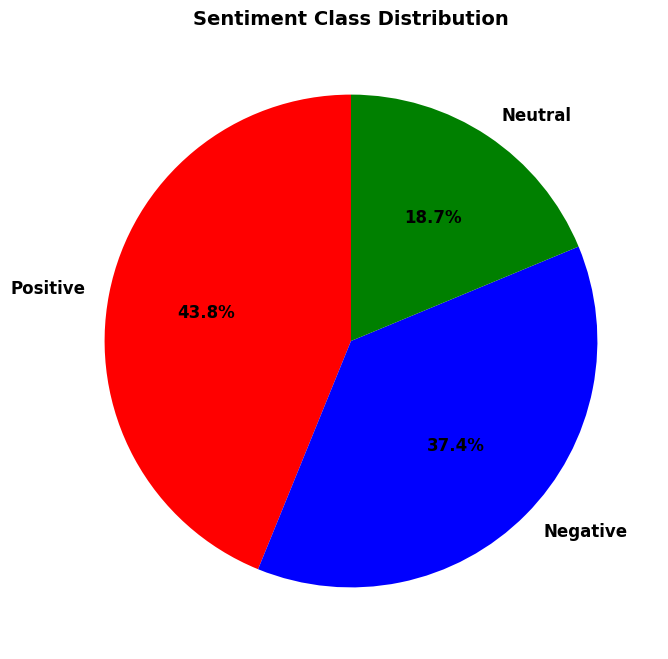

In [9]:
# step 1.5
class_counts = df_train['Label'].value_counts()
class_percentages = df_train['Label'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 8))
plt.pie(class_counts.values,
        labels=class_counts.index,
        autopct='%1.1f%%',
        colors=['red', 'blue', 'green'],
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
plt.show()

/tmp/ipykernel_503/4026256025.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


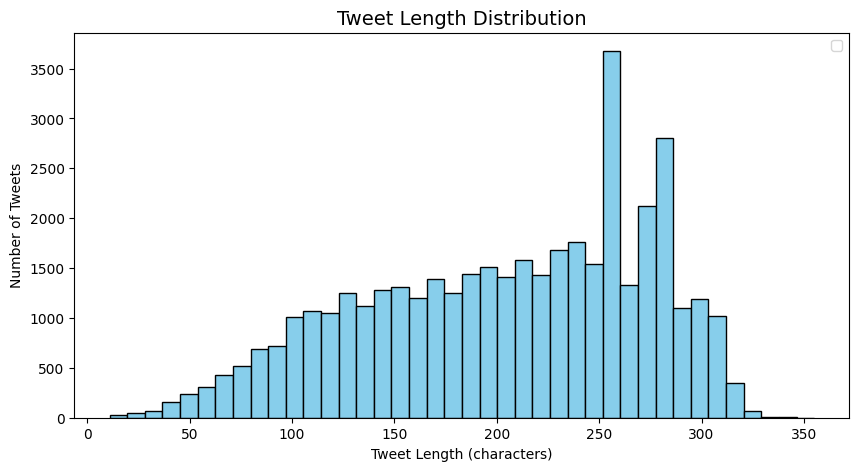

In [10]:
df_train['Text_Length'] = df_train['Text'].str.len()
plt.figure(figsize=(10, 5))

# Histogram
plt.hist(df_train['Text_Length'], bins=40, color='skyblue', edgecolor='black')
plt.title('Tweet Length Distribution', fontsize=14)
plt.xlabel('Tweet Length (characters)')
plt.ylabel('Number of Tweets')
plt.legend()

plt.show()


1. The dataset is imbalanced
2. Positive with 43.8%
3. Model might have biases and predict most tweets to be positive which leads to less accuracy

Part 2

In [11]:
!pip install nltk emoji contractions
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import emoji
import contractions


url_pattern = r'http[s]?://\S+|www\.\S+'
alpha_pattern = r'[^a-zA-Z\s]'
whitespace_pattern = r'\s+'
html_tags_pattern = r'<.*?>|&.*?;|\\n|\\xa0'

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

def clean_text(text):
    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(url_pattern, '', text)

    # Remove HTML tags
    text = re.sub(html_tags_pattern, '', text)

    # Remove non-alphabetic characters
    text = re.sub(alpha_pattern, ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Remove emojis
    text = emoji.replace_emoji(text, replace='')

    # Tokenize and remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords.words('english')]

    # Lemmatize tokens
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.5 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [12]:
test_text = """
RT @john_doe123: I'm SO #depressed today 😢💔
This COVID-19 situation is just TERRIBLE!!!
Can't WAIT for it to end... 😤 #StayHome #COVID19
Visit https://covid19.com for updates & check www.who.int
I <3 my family but this is NOT okay...
🙏 Praying for everyone ❤️
Check out my blog at http://bit.ly/abc123
#Lockdown2020 #StaySafe
"""
clean_text(test_text)
# it works just fine

'rt john doe depressed today covid situation terrible cannot wait end stayhome covid visit update check family okay praying everyone check blog lockdown staysafe'

Part 3

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


df_train['Cleaned_Text'] = df_train['Text'].apply(clean_text)


encoder = LabelEncoder()
df_train['Label_Encoded'] = encoder.fit_transform(df_train['Label'])
X = df_train['Cleaned_Text'].values
y = df_train['Label_Encoded'].values

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2, stratify=y
)

In [15]:
print(f'Training set shape is {X_train.shape[0]}')
print(f'Testing set shape is {X_test.shape[0]}')
for i, label in enumerate(encoder.classes_):
    print(f"{label} → {i}")

Training set shape is 32925
Testing set shape is 8232
Negative → 0
Neutral → 1
Positive → 2


Part 5 RNN

In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Bidirectional, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

token = Tokenizer()

token.fit_on_texts(X_train)

X_train_tok = token.texts_to_sequences(X_train)
X_test_tok = token.texts_to_sequences(X_test)

print(f"Training sequences: {len(X_train_tok)}")
print(f"Testing sequences: {len(X_test_tok)}")
print(f"Vocabulary size: {len(token.word_index)}")

X_train_pad = pad_sequences(X_train_tok, padding='pre')
X_test_pad = pad_sequences(X_test_tok, padding='pre')

print(f"\nTraining padded shape: {X_train_pad.shape}")
print(f"Testing padded shape: {X_test_pad.shape}")


Training sequences: 32925
Testing sequences: 8232
Vocabulary size: 42245

Training padded shape: (32925, 46)
Testing padded shape: (8232, 36)


In [17]:
model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=len(token.word_index)+1, output_dim=64,
                       input_length=X_train_pad.shape[1] ))
model_rnn.add(SimpleRNN(64, return_sequences=False))
model_rnn.add(Dropout(0.5))
model_rnn.add(Dense(64, activation='relu'))

model_rnn.add(Dropout(0.5))
model_rnn.add(Dense(3, activation='softmax'))

model_rnn.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4716 - loss: 0.9755 - val_accuracy: 0.5525 - val_loss: 0.8906
Epoch 2/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7329 - loss: 0.6534 - val_accuracy: 0.7417 - val_loss: 0.6693
Epoch 3/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8908 - loss: 0.3155 - val_accuracy: 0.7379 - val_loss: 0.7540
Epoch 4/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9523 - loss: 0.1541 - val_accuracy: 0.7339 - val_loss: 0.9661
Epoch 5/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9701 - loss: 0.0945 - val_accuracy: 0.7238 - val_loss: 1.2554


In [18]:
model_rnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 46, 64)         │     2,703,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,149,067 (31.09 MB)

 Trainable params: 2,716,355 (10.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,432,712 (20.72 MB)

1. It performs poorly because it has limited memory and struggles with long sequences
2. It occurs when learning signals become so small during backpropagation that the model stops learning from earlier words in a sequence
3. It is better because it has special "memory cells" and "gates" that control what information to remember and forget

Part 6 LSTM

In [19]:
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=len(token.word_index)+1,
                         output_dim=128,
                        input_length=X_train_pad.shape[1]))
model_lstm.add(Bidirectional(LSTM(64, return_sequences=False)))
model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(64, activation='relu'))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(3, activation='softmax'))

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.6491 - loss: 0.7775 - val_accuracy: 0.7836 - val_loss: 0.5628
Epoch 2/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8710 - loss: 0.3892 - val_accuracy: 0.7998 - val_loss: 0.5547
Epoch 3/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9284 - loss: 0.2337 - val_accuracy: 0.8008 - val_loss: 0.6370
Epoch 4/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9534 - loss: 0.1546 - val_accuracy: 0.7862 - val_loss: 0.7397
Epoch 5/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9651 - loss: 0.1162 - val_accuracy: 0.7819 - val_loss: 0.8527


In [20]:
model_lstm.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 46, 128)        │     5,407,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,544,267 (63.11 MB)

 Trainable params: 5,514,755 (21.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,029,512 (42.07 MB)

Test Accuracy: 0.8163
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

    Negative       0.81      0.83      0.82      3080
     Neutral       0.81      0.64      0.72      1543
    Positive       0.82      0.88      0.85      3609

    accuracy                           0.82      8232
   macro avg       0.82      0.78      0.80      8232
weighted avg       0.82      0.82      0.81      8232

[[2544  128  408]
 [ 262  995  286]
 [ 325  103 3181]]


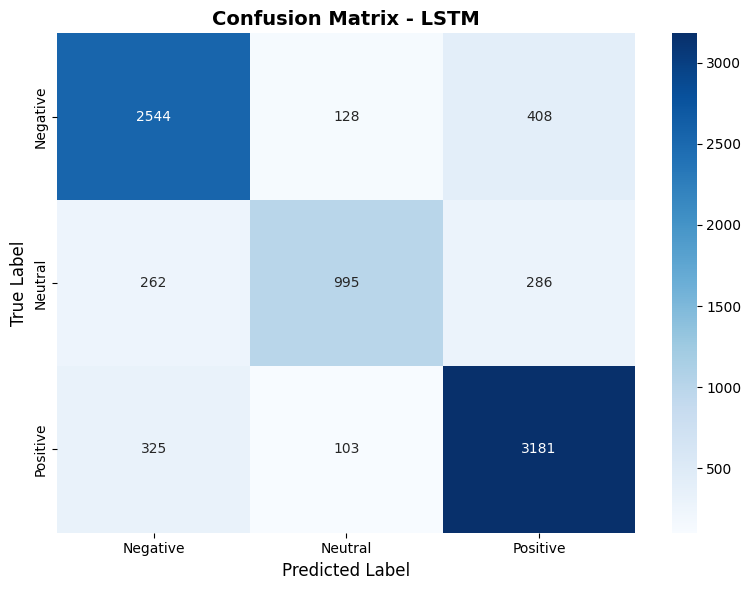

In [21]:
import seaborn as sns

test_loss, test_accuracy = model_lstm.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_probs = model_lstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("="*60)
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

print("="*60)
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title('Confusion Matrix - LSTM', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

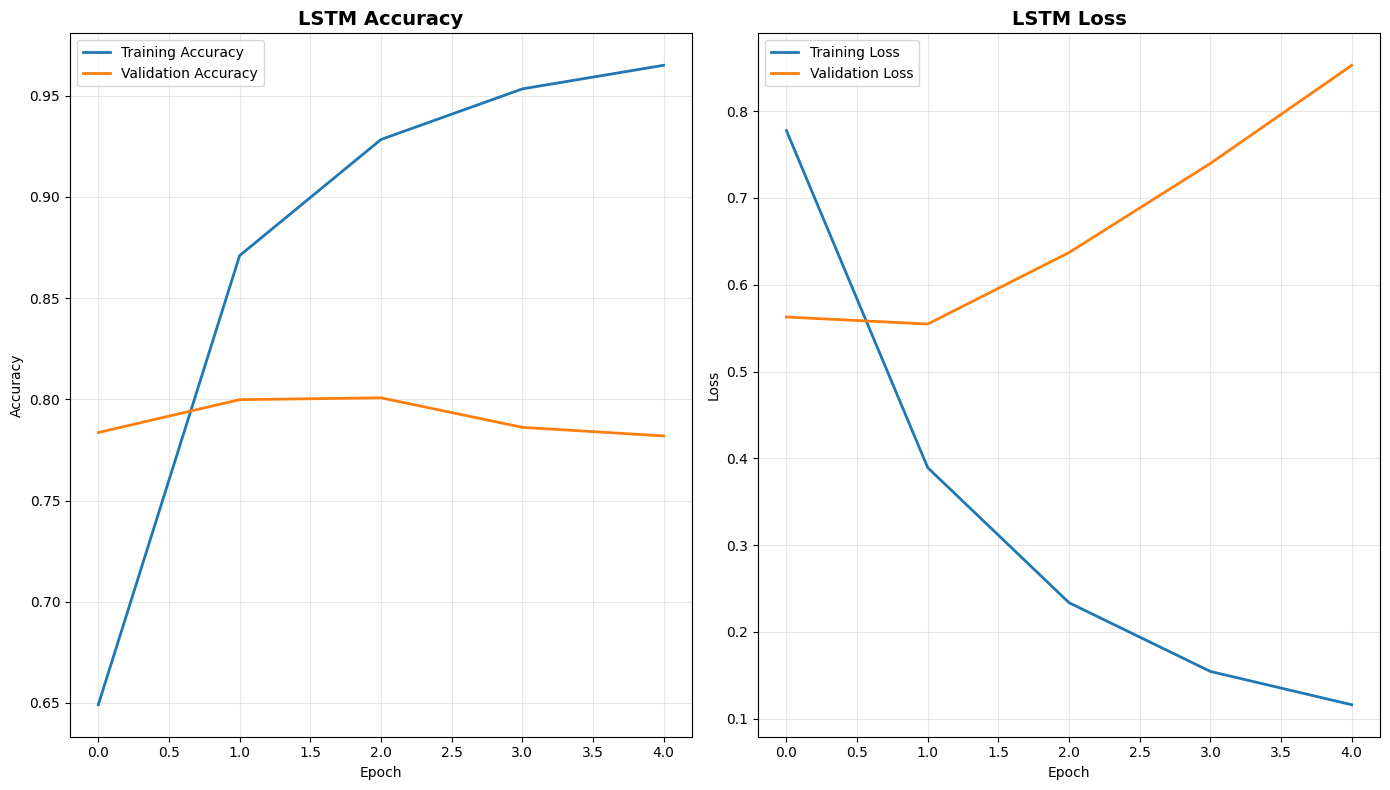

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Accuracy
ax1.plot(history_lstm.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('LSTM Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history_lstm.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history_lstm.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('LSTM Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. LSTM performs better because it has special memory cells and gates
2. By processing text sequentially one word at a time, while maintaining an internal state that shows what it learned so far
3. It is slower, transformers can remember perfectly, transfer can understand context

Part 7 BERT

In [23]:
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

df_train_bert = pd.DataFrame({
    'text': X_train,
    'label': y_train
})

df_test_bert = pd.DataFrame({
    'text': X_test,
    'label': y_test
})

print(df_train_bert.head(10))

train_dataset = Dataset.from_pandas(df_train_bert)
test_dataset = Dataset.from_pandas(df_test_bert)

print(f"\nTraining dataset: {len(train_dataset)} samples")
print(f"Testing dataset: {len(test_dataset)} samples")
print(f"Dataset columns: {train_dataset.column_names}")

                                                text  label
0  much online shopping told self isolate way get...      0
1  keep date nclc consumer advocacy resource prot...      0
2  enlink said wednesday laid employee workforce ...      0
3  plenty empty shelf walmart covid coronavirus w...      0
4  shop passing price farmer gouging u helped sup...      2
5  hello welcome everyone quarantined state gover...      2
6  bought green pepper grocery store sure eat col...      0
7  department education provides covid guidance c...      1
8  let remember grocery store worker hero praise ...      2
9  chris dillon real estate author founder dillon...      1

Training dataset: 32925 samples
Testing dataset: 8232 samples
Dataset columns: ['text', 'label']


In [24]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)

X_train_bert = X_train
X_test_bert = X_test
y_train_bert = y_train
y_test_bert = y_test

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

model_bert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=3
)



config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/32925 [00:00<?, ? examples/s]

Map:   0%|          | 0/8232 [00:00<?, ? examples/s]

In [26]:
training_args = TrainingArguments(
    output_dir='my_best_model_sentiment',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
)

trainer = Trainer(
    model=model_bert,
    args=training_args,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)



In [27]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.448730,0.410287,0.862974,0.865206,0.862974,0.862513
2,0.346265,0.383651,0.877794,0.878158,0.877794,0.877166
3,0.276056,0.398643,0.881681,0.881858,0.881681,0.881136


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6174, training_loss=0.3975792746733878, metrics={'train_runtime': 1211.8791, 'train_samples_per_second': 81.506, 'train_steps_per_second': 5.095, 'total_flos': 3271175161286400.0, 'train_loss': 0.3975792746733878, 'epoch': 3.0})

In [28]:
predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(y_test, y_pred_bert)

print(cm)

[[2735   82  263]
 [ 148 1226  169]
 [ 243   69 3297]]


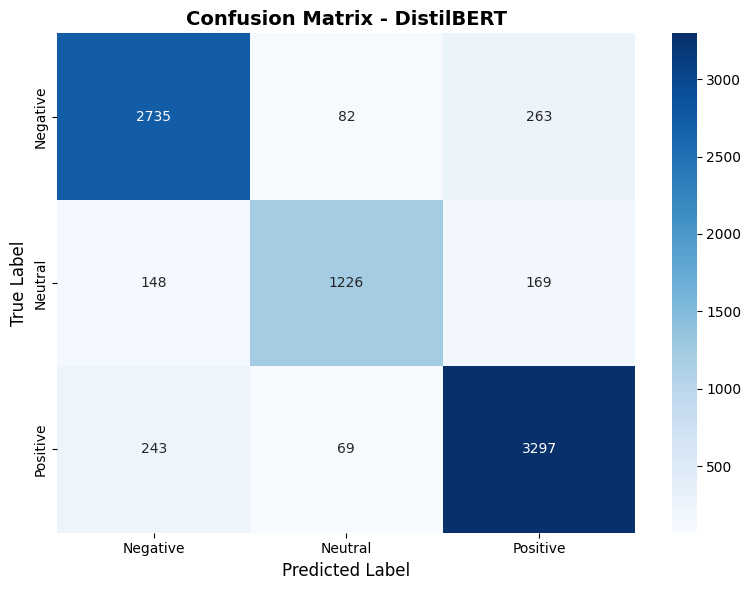

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title('Confusion Matrix - DistilBERT', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

1. DistilBERT uses its own tokenizer because it needs to handle text differently than regular tokenizers
2. Transformers outperform LSTM because they process text differently and have built-in language understanding also because they have more memory and speed
3. BERT reads all the words in one go but LSTM reads one by one, BERT can understand context fully but LSTM cant

In [30]:
pipe = pipeline(
    "text-classification",
    model=model_bert,           # Your trained model
    tokenizer=tokenizer
)

# i needed to apply mapping because it only showed label numbers not pos neg neu
label_map = {
    'LABEL_0': 'Negative',
    'LABEL_1': 'Neutral',
    'LABEL_2': 'Positive'
}

# pipe('The COVID 19 is soo good')

result = pipe('The COVID 19 is reaching the world')[0]
sentiment = label_map[result['label']]
confidence = result['score']

print(f"   Sentiment: {sentiment}")
print(f"   Confidence: {confidence:.2%}")

   Sentiment: Positive
   Confidence: 89.31%


Part 8

In [31]:
import os
import pickle
import json

if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# There was a problem with my tokens so I made another token
keras_tokenizer = Tokenizer()
keras_tokenizer.fit_on_texts(X_train)  # X_train is training text

print(f"Keras tokenizer created with {len(keras_tokenizer.word_index)} words")

# save RNN model
model_rnn.save('saved_models/rnn_model.keras')
print("rnn_model.keras saved")

# save LSTM model
model_lstm.save('saved_models/lstm_model.keras')
print("lstm_model.keras saved")

# save KERAS tokenizer
with open('saved_models/keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(keras_tokenizer, f)
print("keras_tokenizer.pkl saved")

# save label encoder
with open('saved_models/label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print("label_encoder.pkl saved")

# save sequence config
vocab_size = len(keras_tokenizer.word_index) + 1  # +1 for padding
max_len = X_train_pad.shape[1]

sequence_config = {
    'max_len': int(max_len),
    'vocab_size': int(vocab_size)
}

with open('saved_models/sequence_config.json', 'w') as f:
    json.dump(sequence_config, f, indent=4)
print(f"sequence_config.json saved (max_len: {max_len}, vocab_size: {vocab_size})")

# save DistilBERT model
model_bert.save_pretrained('saved_models/bert_sentiment_model')
tokenizer.save_pretrained('saved_models/bert_sentiment_model')

saved_files = os.listdir('saved_models')

# Verification
required_files = [
    'rnn_model.keras',
    'lstm_model.keras',
    'keras_tokenizer.pkl',
    'label_encoder.pkl',
    'sequence_config.json',
    'bert_sentiment_model'
]

for file in required_files:
    if file in saved_files:
        print(f"{file} - FOUND")
    else:
        print(f"{file} - MISSING")

bert_folder = 'saved_models/bert_sentiment_model'
if os.path.exists(bert_folder):
    bert_files = os.listdir(bert_folder)
    print(f"\nbert_sentiment_model/ contains:")
    for f in bert_files:
        print(f)
    print(f"\nTotal: {len(bert_files)} files")


Keras tokenizer created with 42245 words
rnn_model.keras saved
lstm_model.keras saved
keras_tokenizer.pkl saved
label_encoder.pkl saved
sequence_config.json saved (max_len: 46, vocab_size: 42246)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

rnn_model.keras - FOUND
lstm_model.keras - FOUND
keras_tokenizer.pkl - FOUND
label_encoder.pkl - FOUND
sequence_config.json - FOUND
bert_sentiment_model - FOUND

bert_sentiment_model/ contains:
model.safetensors
tokenizer_config.json
config.json
tokenizer.json

Total: 4 files


In [32]:
requirements = """
tensorflow
numpy
pandas
scikit-learn
emoji
transformers
torch
contractions
nltk
matplotlib
seaborn
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

print("\nContents:")
print(requirements.strip())



Contents:
tensorflow
numpy
pandas
scikit-learn
emoji
transformers
torch
contractions
nltk
matplotlib
seaborn


After training 3 models RNN LSTM and DistlBERT I would say DistilBERT preformed the best with an accuracy of 0.876944 as it did not overfit unlike RNN (accuracy 0.9724) and LSTM (accuracy 0.9645), their accuracies were increasing however the validation accuracy stopped increasing and started decreasing after 2 epochs usually

LSTM is better than RNN as it has more memory cells it fixes the vanishing gradident problem

BERT in general is trained much more than LSTM with billions of words from wikipedia etc. Also, BERT can read all the words at once unlike LSTM which is one by one and BERT remembers everything unlike LSTM
